### SCRIPT 4.1 ###
- Installing and importing necessary packages

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as LA
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import *
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator
simulator = AerSimulator()
from qiskit import transpile
from qiskit.visualization import plot_histogram

### SCRIPT 4.2 ###
- 2-site Hisenberg spin chain Hamiltonian and propagator

In [20]:
J = 1
h0 =-0.5
h1 = 0.5
X = np.array([[0,1],[1,0]], dtype = complex)
Y = np.array([[0,1j],[1j,0]], dtype = complex)
Z = np.array([[1,0],[0,-1]], dtype = complex)
I = np.array([[1,0],[0,1]], dtype = complex)
H = 0.5 * (h0 * np.kron(Z, I) + h1 * np.kron(I, Z)) + J / 4 * (np.kron(X, X) +
np.kron(Z, Z))
U = LA.expm(-1j * H)

### SCRIPT 4.3 ###
- Classical propagation of 2-site Heisenberg chain

In [21]:
psi_init = np.array([1,0,0,0],dtype = complex)
psi_fin = U @ psi_init
print(psi_fin)

[ 0.93879128-0.23971277j  0.        +0.j          0.        +0.j
 -0.06120872-0.23971277j]


### SCRIPT 4.4 ###
- Quantum circuit for the 2-site Heisenberg chain propagation
initiation

In [22]:
qreg=QuantumRegister(2) # qreg is filled with two qubits
creg=ClassicalRegister(2) # creg is filled with two classical bits
entangler=QuantumCircuit(qreg,creg) # we put together our qreg and creg to make our 
                                    #Quantum Circuit, called entangler here.
#entangler.initialize(psi_init) #Not necessary since we start at |00>

### SCRIPT 4.5 ###
- Quantum circuit for the 2-site Heisenberg chain propagation
gate construction

In [23]:
U_gate = Operator(U)            # matriks U dijadikan operator quantum
entangler.append(U_gate,[0,1])  # diterapkan ke qubit 0 dan 1

### SCRIPT 4.6 ###
- Quantum circuit for the 2-site Heisenberg chain propagation
measurement

In [24]:
entangler.measure(0,0) # measure the first qubit and record it in the first classical bit
entangler.measure(1,1)
entangler.draw()

┌──────────┐┌─┐   
q1_0: ┤0         ├┤M├───
      │  Unitary │└╥┘┌─┐
q1_1: ┤1         ├─╫─┤M├
      └──────────┘ ║ └╥┘
c1: 2/═════════════╩══╩═
                   0  1

### SCRIPT 4.7 ###
- Accessing IBM account from API token

In [25]:
# ============================================================
# Scripts 4.7–4.9 (Updated): IBM Account & QASM Simulator
# ============================================================

# --- Cara menyimpan akun IBM (lakukan sekali) ---
QiskitRuntimeService.save_account(channel="ibm_quantum_platform",token="LI2WzxI8mWdduBWOUSrLIM78exCFTSG4jJIoTAfEbd9o",overwrite=True)

# --- Menjalankan di LOKAL simulator (tanpa akun IBM) ---
# Ini padanan "QASM simulator" namun gratis & offline

# Qiskit 2.x: gunakan AerSimulator sebagai pengganti BasicAer
# AerSimulator mode 'statevector': simulasi deterministik tanpa noise
aer_sim = AerSimulator(method='statevector')

# Transpile: kompilasi circuit ke basis gates yang didukung simulator
# Analogi: seperti compile kode Python ke bytecode yang bisa dijalankan mesin
qc_transpiled = transpile(entangler, aer_sim)

# Jalankan circuit dengan 2000 shots
# "shots" = berapa kali eksperimen diulang untuk mendapat statistik
job = aer_sim.run(qc_transpiled, shots=2000)
result = job.result()
counts = result.get_counts()

# Konversi counts ke probabilitas
total_shots = sum(counts.values())
probs = {k: v/total_shots for k, v in counts.items()}

print("Hasil QASM Simulator (Aer):")
print("Counts:", counts)
print("Probabilitas:", {k: round(v, 4) for k, v in probs.items()})
print("Probabilitas klasik |00⟩:", round(np.abs(psi_fin[0])**2, 4))
print("Probabilitas klasik |11⟩:", round(np.abs(psi_fin[3])**2, 4))

Hasil QASM Simulator (Aer):
Counts: {'11': 136, '00': 1864}
Probabilitas: {'11': 0.068, '00': 0.932}
Probabilitas klasik |00⟩: 0.9388
Probabilitas klasik |11⟩: 0.0612


### SCRIPT 4.8 ###
- Run dynamics with QASM simulator

{'11': 107, '00': 1893}


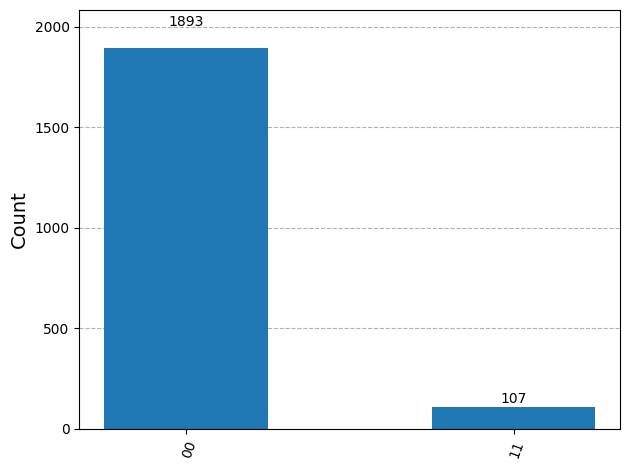

In [26]:
simulator = AerSimulator()
compiled  = transpile(entangler, simulator)
result    = simulator.run(compiled, shots=2000).result()
counts    = result.get_counts()
print(counts)
plot_histogram(counts)

### SCRIPT 4.9 ###
- Measure results from QASM simulator

[0.9465 0.     0.     0.0535]


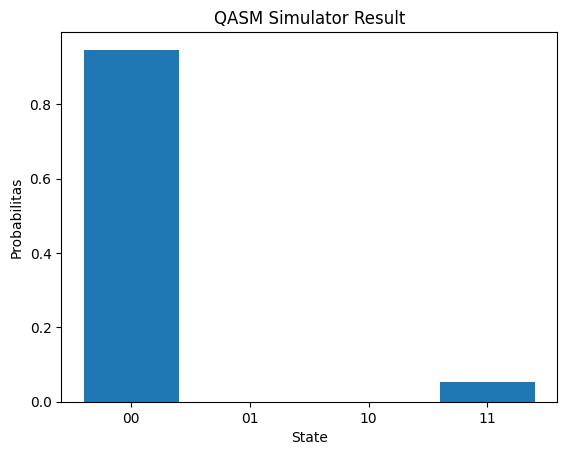

In [27]:
# Kode asli pakai IBM Sampler, ganti dengan Aer

qasm_result = np.zeros((4,))
qasm_result[0] = counts.get('00', 0) / 2000
qasm_result[1] = counts.get('01', 0) / 2000
qasm_result[2] = counts.get('10', 0) / 2000
qasm_result[3] = counts.get('11', 0) / 2000
print(qasm_result)
plt.bar(['00', '01', '10', '11'], qasm_result)
plt.xlabel('State')
plt.ylabel('Probabilitas')
plt.title('QASM Simulator Result')
plt.show()


In [28]:
import qutip as qt

# Samakan parameter dengan file 4
J  = 1
h0 = -0.5
h1 = 0.5

# Operator
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()
I = qt.qeye(2)

# Hamiltonian sama persis dengan file 4
H_qt = 0.5 * (h0 * qt.tensor(Z, I) + h1 * qt.tensor(I, Z)) + \
       J/4 * (qt.tensor(X, X) + qt.tensor(Z, Z))

# State awal |00⟩ (sama dengan psi_init = [1,0,0,0])
psi0_qt = qt.tensor(qt.basis(2,0), qt.basis(2,0))

# Waktu t=1 (sama dengan LA.expm(-1j * H))
tlist  = np.linspace(0, 1, 200)
result = qt.mesolve(H_qt, psi0_qt, tlist, [], [])

# Probabilitas eigenstate akhir
psi_final    = result.states[-1]
classical    = np.zeros(4)
classical[0] = abs(psi_final.overlap(qt.tensor(qt.basis(2,0), qt.basis(2,0))))**2
classical[1] = abs(psi_final.overlap(qt.tensor(qt.basis(2,0), qt.basis(2,1))))**2
classical[2] = abs(psi_final.overlap(qt.tensor(qt.basis(2,1), qt.basis(2,0))))**2
classical[3] = abs(psi_final.overlap(qt.tensor(qt.basis(2,1), qt.basis(2,1))))**2

print("Classical:", classical)
print("QASM:     ", qasm_result)

Classical: [0.93879124 0.         0.         0.06120876]
QASM:      [0.9465 0.     0.     0.0535]


/mgpfs/home/shakim/miniconda3/envs/qiskit_env/lib/python3.10/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


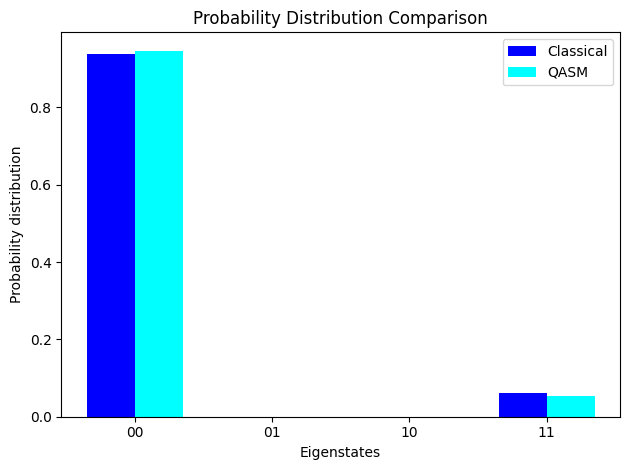

In [29]:
x     = np.arange(4)
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, classical,   width, label='Classical', color='blue')
ax.bar(x + width/2, qasm_result, width, label='QASM',      color='cyan')

ax.set_xticks(x)
ax.set_xticklabels(['00', '01', '10', '11'])
ax.set_xlabel('Eigenstates')
ax.set_ylabel('Probability distribution')
ax.set_title('Probability Distribution Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### SCRIPT 4.10 ###
-  Measure results from QASM simulator

In [30]:
# ============================================================
# Script 4.10 (Fully Fixed): Menjalankan di IBM Real Machine
# qiskit_ibm_runtime >= 0.40
# ============================================================

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import numpy as np
import matplotlib.pyplot as plt

# --- LANGKAH 1: Koneksi ke service (sudah berhasil sebelumnya) ---
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(f"Backend: {backend.name}")
print(f"Jumlah qubit: {backend.num_qubits}")
print(f"Basis gates: {backend.basis_gates}")

# --- LANGKAH 2: Rebuild circuit entangler ---
# (pastikan circuit sudah didefinisikan dengan benar dari Script 4.4-4.6)
import scipy.linalg as LA
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator

J=1; h0=-0.5; h1=0.5
X=np.array([[0,1],[1,0]],dtype=complex)
Y=np.array([[0,-1j],[1j,0]],dtype=complex)
Z=np.array([[1,0],[0,-1]],dtype=complex)
I=np.eye(2,dtype=complex)

H_mat = (0.5*(h0*np.kron(Z,I) + h1*np.kron(I,Z))
         + (J/4)*(np.kron(X,X) + np.kron(Y,Y) + np.kron(Z,Z)))
U     = LA.expm(-1j * H_mat)

# Circuit dengan register bernama (penting untuk akses hasil di V2)
qreg     = QuantumRegister(2, name='q')
creg     = ClassicalRegister(2, name='c')   # nama 'c' akan dipakai saat akses hasil
entangler = QuantumCircuit(qreg, creg)
entangler.append(Operator(U), [0, 1])
entangler.measure(0, 0)
entangler.measure(1, 1)

print("\nCircuit sebelum transpile:")
print(entangler.draw(output='text'))
print(f"Depth sebelum transpile: {entangler.depth()}")

# --- LANGKAH 3: Transpile ke ISA (Instruction Set Architecture) backend ---
# generate_preset_pass_manager adalah cara RESMI dan WAJIB untuk hardware IBM
# Ini menerjemahkan circuit ke basis gates hardware (CNOT, RZ, SX, X, ...)
# optimization_level: 0 (cepat, kurang optimal) s.d. 3 (lambat, paling optimal)
# Untuk eksperimen sederhana, level 1 sudah cukup

pm          = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(entangler)  # circuit yang siap dikirim ke hardware

print(f"\nCircuit setelah transpile (ISA):")
print(isa_circuit.draw(output='text', fold=80))
print(f"Depth setelah transpile: {isa_circuit.depth()}")
print(f"Basis gates yang digunakan: {set(isa_circuit.count_ops().keys())}")

# --- LANGKAH 4: Jalankan di IBM hardware ---
# PERHATIAN Plan Open:
# Akun Open Plan IBM Quantum TIDAK mendukung Session mode (hanya job mode)
# Gunakan Sampler(mode=backend) langsung — ini adalah "job mode"

# FIX UTAMA: mode=backend, BUKAN backend=backend
sampler = Sampler(mode=backend)
sampler.options.default_shots = 2000

print(f"Submitting job ke {backend.name}...")
job = sampler.run([isa_circuit])

print(f"Job ID: {job.job_id()}")
print(f"Status: {job.status()}")
print("Job ter-submit! Tunggu hasilnya (bisa beberapa menit)...")

# --- LANGKAH 5: Ambil dan proses hasil ---
# Gunakan job.job_id() untuk cek status nanti tanpa menunggu di notebook

# Cara 1: tunggu langsung (blok sampai selesai)
result      = job.result()
pub_result  = result[0]

# SamplerV2 V2: akses via .data.NAMA_REGISTER.get_counts()
# Nama register = 'c' sesuai ClassicalRegister(2, name='c') yang kita definisikan
counts_real = pub_result.data.c.get_counts()
total_shots  = sum(counts_real.values())

print(f"Raw counts: {counts_real}")

# Konversi ke probabilitas
# Catatan: Qiskit output little-endian — bit paling kanan = qubit index 0
# '00' = |q1=0, q0=0⟩ = |00⟩
# '11' = |q1=1, q0=1⟩ = |11⟩
probs_real = {k: v/total_shots for k, v in counts_real.items()}
print(f"Probabilitas (hardware): {probs_real}")

# Cara 2: cek job nanti via job ID (tidak perlu tunggu)
# job_saved = service.job("JOB_ID_KAMU")
# if job_saved.status() == "DONE":
#     counts = job_saved.result()[0].data.c.get_counts()

# --- LANGKAH 6: Visualisasi lengkap (klasik + simulator + hardware) ---

# Classical benchmark
psi_init  = np.array([1,0,0,0], dtype=complex)
psi_fin   = U @ psi_init
classical_probs = np.abs(psi_fin)**2

# Simulator AerSimulator (kita sudah punya dari sebelumnya)
from qiskit_aer import AerSimulator
from qiskit import transpile

aer_sim      = AerSimulator(method='statevector')
qc_aer       = transpile(entangler, aer_sim)
aer_result   = aer_sim.run(qc_aer, shots=2000).result()
counts_aer   = aer_result.get_counts()
probs_aer    = {k: v/2000 for k, v in counts_aer.items()}

# Siapkan array untuk plotting
labels   = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
keys_bin = ['00', '01', '10', '11']

# Konversi: Qiskit output bisa tidak mengikutkan state dengan count 0
def get_prob(probs_dict, key, total=1):
    return probs_dict.get(key, 0)

sim_arr  = [get_prob(probs_aer,  k) for k in keys_bin]
real_arr = [get_prob(probs_real, k) for k in keys_bin]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(4)
ax.bar(x-0.25, classical_probs, 0.25, label='Classical (exact)',     color='steelblue')
ax.bar(x,      sim_arr,         0.25, label='AerSimulator (no noise)', color='orange')
ax.bar(x+0.25, real_arr,        0.25, label=f'IBM {backend.name}',    color='green', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Probability'); ax.set_ylim(0, 1)
ax.set_title('2-site Heisenberg: Classical vs Simulator vs Real Hardware')
ax.legend(); plt.tight_layout(); plt.show()

# Fidelity hardware vs exact
fidelity = sum(np.sqrt(classical_probs[i] * real_arr[i]) for i in range(4))**2
print(f"\nFidelity hardware vs exact: {fidelity:.4f}")
print("(1.0 = sempurna, nilai turun karena noise hardware)")

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'

### SCRIPT 4.11 ###
- Pauli Matrix Decomposition- Utility Functions (yang dipakai untuk mempermudah atau mendukung proses utama)

In [31]:
def vec_query(arr, my_dict):
    '''
    This function vectorizes dictionary querying.
    It allows us to query `my_dict` with a np.array `arr` of keys.
    This avoids a loop through the list of keys.
    '''
    import numpy as np
    return np.vectorize(my_dict.__getitem__, otypes=[tuple])(arr)

def nested_kronecker_product(a):
    '''
    Handles Kronecker Products for list (i.e., a = [Z, Z, Z] will evaluate Z Z Z).
    Given list `a` this recursively evaluates the kronecker product of all elements.
    This allows us to avoid having to call `np.kron` n-1 times for a list of length n.
    '''
    import numpy as np
    if len(a) == 2:
        return np.kron(a[0],a[1])
    else:
        return np.kron(a[0], nested_kronecker_product(a[1:]))
    
def Hilbert_Schmidt(mat1, mat2):
    '''
    Return the Hilbert-Schmidt Inner Product of two matrices.
    This gives the coefficients for each term in the sum of tensor products of Paulis.
    '''
    import numpy as np
    return np.trace(mat1 * mat2)

### SCRIPT 4.12 ###
- Pauli Matrix Decomposition

In [32]:
def decompose(Ham_arr, tol=10):
    '''
    Function that decomposes `Ham_arr` into a sum of Pauli strings.
    '''
    import numpy as np
    import itertools
    X = np.array([[0,1],[1,0]])
    Y = np.array([[0,complex(0,-1)],[complex(0,1),0]])
    Z = np.array([[1,0],[0,-1]])
    I = Z@Z
    # Define a dictionary with the four Pauli matrices:
    pms = {'I': I,'X': X,'Y': Y,'Z': Z}
    pauli_keys = list(pms.keys()) # Keys of the dictionary

    nqb = int(np.log2(Ham_arr.shape[0])) # Determine the # of qubits needed

    # Make all possible tensor products of Pauli matrices sigma
    sigma_combinations = list(itertools.product(pauli_keys, repeat=nqb))

    output_string = '' # Initialize an empty string to which we can add our terms
    for ii in range(len(sigma_combinations)):
        pauli_str = ''.join(sigma_combinations[ii])

        # Convert the Pauli string into a list of matrices
        tmp_mat_list = vec_query(np.array(sigma_combinations[ii]), pms)

        # Evaluate the Kronecker product of the matrix array
        tmp_p_matrix = nested_kronecker_product(tmp_mat_list)

        # Compute the coefficient for each Pauli string
        a_coeff = (1/(2**nqb)) * Hilbert_Schmidt(tmp_p_matrix, Ham_arr)

        # If the coefficient is non-zero, we want to use it!
        if abs(a_coeff) > 10**(-tol):
            output_string += str(np.round(a_coeff.real, 6))+'*'+pauli_str
            output_string += '+' # Add a plus sign for the next term!

    return output_string[:-1] # To ignore that extra plus sign

### SCRIPT 4.13 ###
-  1D PES for A-T tautomerization

In [33]:
import pylatexenc
import itertools
from qiskit.circuit.library import QFT
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

In [34]:
d=6   # number of qubits
mass=1
xMin=-5
xMax=-xMin
x = np.linspace(xMin,xMax, num=2**d)
VV = (0.429*x-1.126*x**2-0.143*x**3+0.563*x**4) * 0.1

### SCRIPT 4.14 ###
- Gaussian initial wavepacket

In [35]:
# Gaussian wavepacket on a grid
mu= 1
alpha = 1
psi = (alpha/np.pi)**(0.25) * np.exp(-alpha * (x-mu)**2 * 0.5)
psi/= np.sqrt(np.sum(np.abs(psi)**2))

### SCRIPT 4.15 ###
- Preparation of potential and kinetic split propagators

In [36]:
# PES and KE operators
dx=(xMax-xMin)/(2**d-1)
# KE operator
dp=2*np.pi/(xMax-xMin)
N=2**d
p=np.zeros(N,dtype=float)
for i in range(N):
  p[i]=dp*(i-N/2)
p=np.fft.fftshift(p)
time_step = 0.01
iterations = 600
VVd_prop=np.diag(np.exp(-1j*VV*time_step))
KEd_prop=np.diag(np.exp(-1j*p**2/2/mass*time_step))

### SCRIPT 4.16 ###
- Quantum SOFT circuit preparation

In [37]:

# Initialize an Empty Circuit
nqubits=d
q_reg=QuantumRegister(nqubits)
c_reg=ClassicalRegister(nqubits)
qc = QuantumCircuit(q_reg)

qc.initialize(psi,q_reg[:])
for k in range(iterations):
  bound_op = Operator(VVd_prop)
  qc.append(bound_op, q_reg)
  qc.append(QFT(d,do_swaps=True,inverse=True),q_reg)
  bound_op = Operator(KEd_prop)
  qc.append(bound_op, q_reg)
  qc.append(QFT(d,do_swaps=True,inverse=False),q_reg)

/tmp/ipykernel_4063338/3349549138.py:11: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d,do_swaps=True,inverse=True),q_reg)
/tmp/ipykernel_4063338/3349549138.py:14: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d,do_swaps=True,inverse=False),q_reg)


### SCRIPT 4.17 ###
- Quantum SOFT circuit execution

In [38]:
from qiskit.quantum_info import Statevector

psin = Statevector(qc)
print(psin)

Statevector([-1.23960251e-05-9.52542071e-06j,
              7.19337967e-07-3.17853239e-05j,
              7.74050567e-06-5.61559498e-05j,
              5.17036285e-05-1.33095131e-04j,
              1.31299586e-04-2.74043879e-04j,
              2.65902436e-04-5.25206996e-04j,
              4.70919395e-04-9.53341891e-04j,
              7.63741598e-04-1.63275419e-03j,
              1.11707064e-03-2.64422812e-03j,
              1.55352895e-03-4.17728233e-03j,
              2.15554110e-03-6.61473499e-03j,
              3.13286849e-03-1.04883686e-02j,
              4.81271477e-03-1.65800107e-02j,
              7.65621274e-03-2.57436904e-02j,
              1.21338888e-02-3.87679844e-02j,
              1.85908350e-02-5.61347184e-02j,
              2.70546167e-02-7.77723999e-02j,
              3.72735471e-02-1.03040713e-01j,
              4.88485114e-02-1.30695198e-01j,
              6.14129811e-02-1.59003362e-01j,
              7.48142408e-02-1.85988859e-01j,
              8.90250497e-02-2.096

### SCRIPT 4.18 ### 
- Clssical SOFT Benchmark

In [39]:
#Classical SOFT routine
def soft(fxy,emat,Pxy):
    # soft propagation
    out=emat*fxy
    fp=np.fft.fft(out)*Pxy
    out=np.fft.ifft(fp)
    return out
psi_c_init = psi
psi_c = psi_c_init
for i in range(iterations):
  psi_c = soft(psi_c,np.diag(VVd_prop),np.diag(KEd_prop))

### SCRIPT 4.19 ### 
- Plotting initial and final wavefunctions

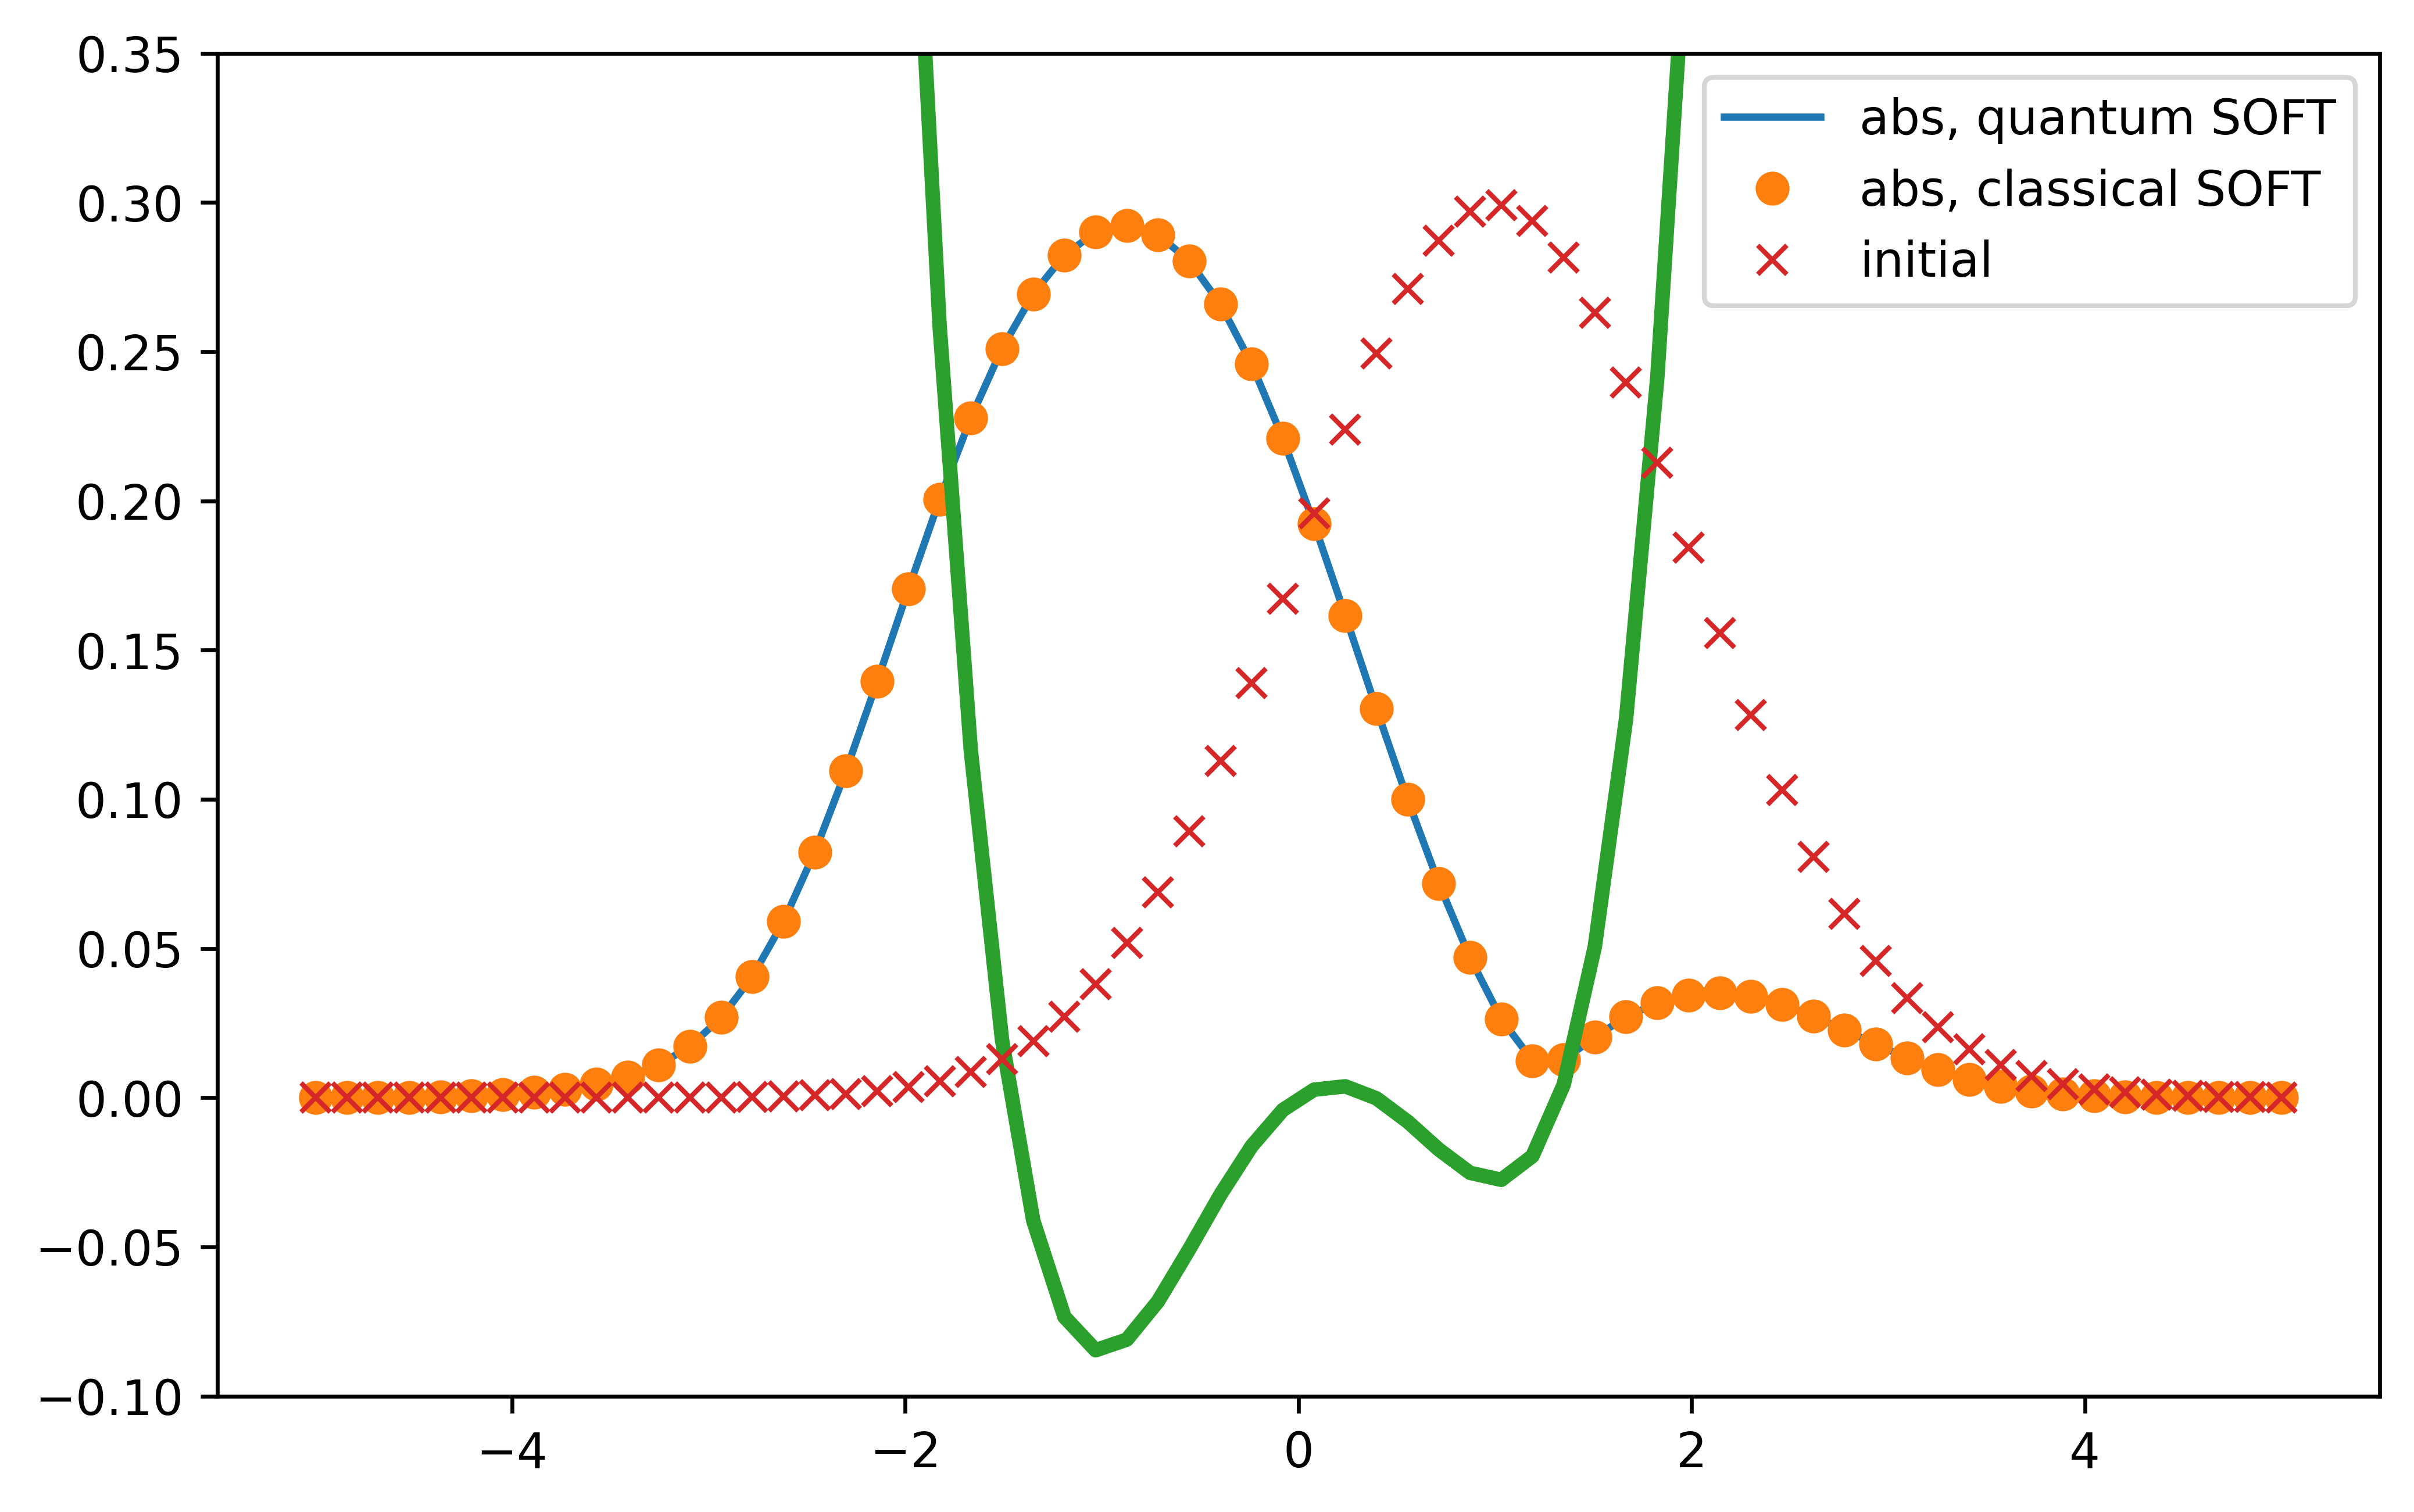

In [40]:
# Visualization
plt.figure(dpi=600, figsize=(8, 5))
plt.rcParams["figure.figsize"] = [12.50, 6.50]
#plt.plot(x,np.real(psin), label='real')
#plt.plot(x,np.imag(psin), label='imag')
plt.plot(x,np.abs(psin), label='abs, quantum SOFT')
plt.plot(x,np.abs(psi_c),'o', label='abs, classical SOFT')
plt.plot(x,VV,linewidth=3)
plt.plot(x,abs(psi),'x', label='initial')
leg = plt.legend(loc='upper right')
plt.ylim(-0.1,0.35)
plt.show()

### SCRIPT 4.20 ###
- Heisenberg Hamiltonian for site n

In [41]:
from qiskit.quantum_info import SparsePauliOp
def get_hamiltonian_n_site_terms(n, coeff, n_qubits):
    XX_coeff = coeff[0]
    YY_coeff = coeff[1]
    ZZ_coeff = coeff[2]
    Z_coeff = coeff[3]

    XX_term = SparsePauliOp(("I" * n + "XX" + "I" * (n_qubits- 2- n)))
    XX_term *= XX_coeff
    YY_term = SparsePauliOp(("I" * n + "YY" + "I" * (n_qubits- 2- n)))
    YY_term *= YY_coeff
    ZZ_term = SparsePauliOp(("I" * n + "ZZ" + "I" * (n_qubits- 2- n)))
    ZZ_term *= ZZ_coeff
    Z_term = SparsePauliOp(("I" * n + "Z" + "I" * (n_qubits- 1- n)))
    Z_term *= Z_coeff
    
    return (XX_term + YY_term + ZZ_term + Z_term)

### SCRIPT 4.21 ###
- Heisenberg Hamiltonian for N Sites

In [42]:
def get_heisenberg_hamiltonian(n_qubits, coeff=None):
    
    # Three qubits because for 2 we get H_O = 0
    assert n_qubits >= 3

    if coeff == None:
        'Setting default values for the coefficients'
        coeff = [[1.0, 1.0, 1.0, 1.0] for i in range(n_qubits)]

    # Even terms of the Hamiltonian
    # (summing over individual pair-wise elements)
    H_E = sum((get_hamiltonian_n_site_terms(i, coeff[i], n_qubits)
            for i in range(0, n_qubits-1, 2)))

    # Odd terms of the Hamiltonian
    # (summing over individual pair-wise elements)
    H_O = sum((get_hamiltonian_n_site_terms(i, coeff[i], n_qubits)
            for i in range(1, n_qubits-1, 2)))
    
    # adding final Z term at the Nth site
    final_term = SparsePauliOp("I" * (n_qubits- 1) + "Z")
    final_term *= coeff[n_qubits-1][3]
    if (n_qubits % 2) == 0:
        H_E += final_term
    else:
        H_O += final_term

    # Returns the list of the two sets of terms
    return [H_E, H_O]

### SCRIPT 4.22 ###
-  Heisenberg Hamiltonian 3 Sites

In [43]:
num_q = 3
# XX YY ZZ, Z
ham_coeffs = ([[0.75/2, 0.75/2, 0.0, 0.65]]
            + [[0.5, 0.5, 0.0, 1.0]
            for i in range(num_q-1)])

spin_chain_hamiltonian = get_heisenberg_hamiltonian(num_q,ham_coeffs)

print('Hamiltonian separated into even and odd components:')
for i, h in enumerate(spin_chain_hamiltonian):
    label = "Even" if i == 0 else "Odd"
    print(f"\n  [{label} component]")
    for pauli, coeff in zip(h.paulis, h.coeffs):
        if coeff.real != 0:
            print(f"    {pauli}  coeff = {coeff.real:.4f}")

print('\nHamiltonian combining even and odd components:')
h_total = sum(spin_chain_hamiltonian)
for pauli, coeff in zip(h_total.paulis, h_total.coeffs):
    if coeff.real != 0:
        print(f"  {pauli}  coeff = {coeff.real:.4f}")

Hamiltonian separated into even and odd components:

  [Even component]
    XXI  coeff = 0.3750
    YYI  coeff = 0.3750
    ZII  coeff = 0.6500

  [Odd component]
    IXX  coeff = 0.5000
    IYY  coeff = 0.5000
    IZI  coeff = 1.0000
    IIZ  coeff = 1.0000

Hamiltonian combining even and odd components:
  XXI  coeff = 0.3750
  YYI  coeff = 0.3750
  ZII  coeff = 0.6500
  IXX  coeff = 0.5000
  IYY  coeff = 0.5000
  IZI  coeff = 1.0000
  IIZ  coeff = 1.0000


### SCRIPT 4.23 ###
- Trotterized Time Evolution Operator

In [44]:
from qiskit.synthesis import SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate
def get_time_evolution_operator(num_qubits, tau, trotter_steps, coeff=None):
    heisenberg_hamiltonian = get_heisenberg_hamiltonian(num_qubits, coeff)
    evo_op = PauliEvolutionGate(heisenberg_hamiltonian, tau, synthesis=SuzukiTrotter(order=2, reps=trotter_steps))
    return evo_op.definition

num_q = 3
evolution_timestep = 0.1
n_trotter_steps = 1
ham_coeffs = ([[0.75/2, 0.75/2, 0.0, 0.65]] + [[0.5, 0.5, 0.0, 1.0] for i in range(num_q-1)])
time_evo_op = get_time_evolution_operator(num_qubits=num_q, tau=evolution_timestep,
            trotter_steps=n_trotter_steps, coeff=ham_coeffs)
print(time_evo_op)

                                     ┌───────────┐┌───────────┐┌─────────┐»
q_0: ────────────────────────────────┤0          ├┤0          ├┤ Rz(0.2) ├»
     ┌──────────────┐┌──────────────┐│  Rxx(0.1) ││  Ryy(0.1) │├─────────┤»
q_1: ┤0             ├┤0             ├┤1          ├┤1          ├┤ Rz(0.2) ├»
     │  Rxx(0.0375) ││  Ryy(0.0375) │├───────────┤└───────────┘└─────────┘»
q_2: ┤1             ├┤1             ├┤ Rz(0.065) ├────────────────────────»
     └──────────────┘└──────────────┘└───────────┘                        »
«                                                  
«q_0: ─────────────────────────────────────────────
«     ┌──────────────┐┌──────────────┐             
«q_1: ┤0             ├┤0             ├─────────────
«     │  Rxx(0.0375) ││  Ryy(0.0375) │┌───────────┐
«q_2: ┤1             ├┤1             ├┤ Rz(0.065) ├
«     └──────────────┘└──────────────┘└───────────┘


* Output itu adalah quantum circuit yang merepresentasikan operator evolusi waktu e−iHt menggunakan Suzuki-Trotter order 2

### Script 4.24 ###
-  Sorting Terms by Interaction order (Mengurutkan suku berdasarkan interaksinya)


In [45]:
import re
from itertools import groupby

def find_string_pattern(pattern, string):
    match_list = []
    for m in re.finditer(pattern, string):
        match_list.append(m.start())
    return match_list
def sort_Pauli_by_symmetry(ham):
    one_qubit_terms = []
    two_qubit_terms = []
    # separating the one-qubit from two-qubit terms
    for term in ham:
        matches = find_string_pattern('X|Y|Z', str(term.paulis[0]))
        pauli_string = term.paulis[0]
        coeff = np.real(term.coeffs[0])
        str_tag = pauli_string.to_label().replace('I', '')
        if len(matches) == 2:
            two_qubit_terms.append((pauli_string, coeff, matches, str_tag))
        elif len(matches) == 1:
            one_qubit_terms.append((pauli_string, coeff, matches, str_tag))

    # sorting the two-qubit terms according to index on which they act
    two_qubit_terms = sorted(two_qubit_terms, key=lambda x: x[2])
    # separating the even from the odd two-qubit terms
    even_two_qubit_terms = list(filter(lambda x: not x[2][0]%2, two_qubit_terms))
    odd_two_qubit_terms = list(filter(lambda x: x[2][0]%2, two_qubit_terms))

    even_two_qubit_terms = [list(v) for i, v in groupby(even_two_qubit_terms,
                            lambda x: x[2][0])]
    odd_two_qubit_terms = [list(v) for i, v in groupby(odd_two_qubit_terms,
                            lambda x: x[2][0])]
    
    return one_qubit_terms, even_two_qubit_terms, odd_two_qubit_terms

# Output
# Panggil fungsi
one_qubit, even_two_qubit, odd_two_qubit = sort_Pauli_by_symmetry(sum(spin_chain_hamiltonian))

print("=== ONE QUBIT TERMS (Medan Magnet) ===")
for pauli, coeff, matches, tag in one_qubit:
    print(f"  {tag}  coeff={coeff:.4f}  posisi={matches}")

print("\n=== EVEN TWO QUBIT TERMS (Interaksi genap) ===")
for group in even_two_qubit:
    print(f"  Grup qubit {group[0][2][0]}:")
    for pauli, coeff, matches, tag in group:
        print(f"    {tag}  coeff={coeff:.4f}  posisi={matches}")

print("\n=== ODD TWO QUBIT TERMS (Interaksi ganjil) ===")
for group in odd_two_qubit:
    print(f"  Grup qubit {group[0][2][0]}:")
    for pauli, coeff, matches, tag in group:
        print(f"    {tag}  coeff={coeff:.4f}  posisi={matches}")

=== ONE QUBIT TERMS (Medan Magnet) ===
  Z  coeff=0.6500  posisi=[0]
  Z  coeff=1.0000  posisi=[1]
  Z  coeff=1.0000  posisi=[2]

=== EVEN TWO QUBIT TERMS (Interaksi genap) ===
  Grup qubit 0:
    XX  coeff=0.3750  posisi=[0, 1]
    YY  coeff=0.3750  posisi=[0, 1]

=== ODD TWO QUBIT TERMS (Interaksi ganjil) ===
  Grup qubit 1:
    XX  coeff=0.5000  posisi=[1, 2]
    YY  coeff=0.5000  posisi=[1, 2]


### SCRIPT 4.25 ###
-  Circuit for Exponential of 1-Qubit Pauli Term

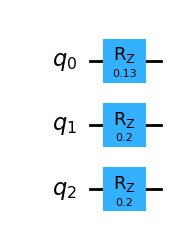

In [46]:
from qiskit import QuantumCircuit

def generate_circ_pattern_1qubit(circ, term, delta_t):
    coeff = 2 * term[1] * delta_t
    if term[3] == 'X':
        circ.rx(coeff, term[2])
    elif term[3] == 'Y':
        circ.ry(coeff, term[2])
    elif term[3] == 'Z':
        circ.rz(coeff, term[2])
    return circ


# Buat circuit kosong 3 qubit
circ = QuantumCircuit(3)

# Ambil one qubit terms dan generate circuit
for term in one_qubit:
    circ = generate_circ_pattern_1qubit(circ, term, delta_t=evolution_timestep)

# Gambar circuit
circ.draw('mpl')

### SCRIPT 4.26 ###
- Circuit for Exponential of 2-Qubit Pauli Term

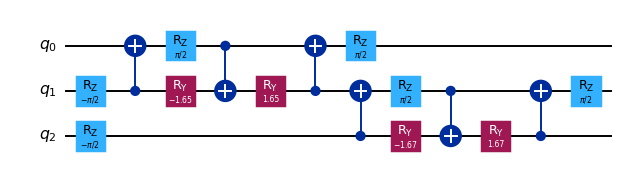

In [47]:
def generate_circ_pattern_2qubit(circ, term, delta_t):
    # wires to which to apply the operation
    wires = term[0][2]

    # angles to parameterize the circuit,
    # based on exponential argument
    if any('XX' in sublist for sublist in term):
        g_phi = ( 2 * (-1) * term[0][1] * delta_t- np.pi / 2)
    else:
        g_phi =- np.pi / 2
    if any('YY' in sublist for sublist in term):
        g_lambda = (np.pi/2- 2 * (-1) * term[1][1] * delta_t)
    else:
        g_lambda = np.pi/2
    if any('ZZ' in sublist for sublist in term):
        g_theta = (np.pi/2- 2 * (-1) * term[2][1] * delta_t)
    else:
        g_theta = np.pi/2

    # circuit
    circ.rz(-np.pi/2, wires[1])
    circ.cx(wires[1], wires[0])
    circ.rz(g_theta, wires[0])
    circ.ry(g_phi, wires[1])
    circ.cx(wires[0], wires[1])
    circ.ry(g_lambda, wires[1])
    circ.cx(wires[1], wires[0])
    circ.rz(np.pi/2, wires[0])
    return circ

# Buat circuit kosong 3 qubit
circ = QuantumCircuit(3)

# Even two qubit
for group in even_two_qubit:
    circ = generate_circ_pattern_2qubit(circ, group, delta_t=evolution_timestep)

# Odd two qubit
for group in odd_two_qubit:
    circ = generate_circ_pattern_2qubit(circ, group, delta_t=evolution_timestep)

circ.draw('mpl', scale=0.7)

### SCRIPT 4.27 ###
- Manual Trotterization of Propagator

Basic depth:     13
Symmetric depth: 21

Basic ops:     OrderedDict([('rz', 9), ('cx', 6), ('ry', 4)])
Symmetric ops: OrderedDict([('rz', 15), ('cx', 9), ('ry', 6)])
=== BASIC ===


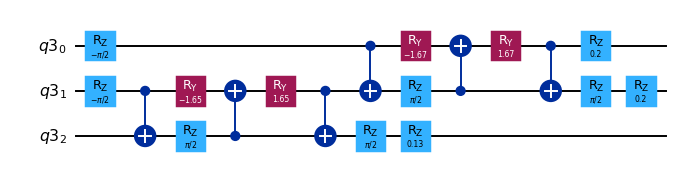

=== SYMMETRIC ===


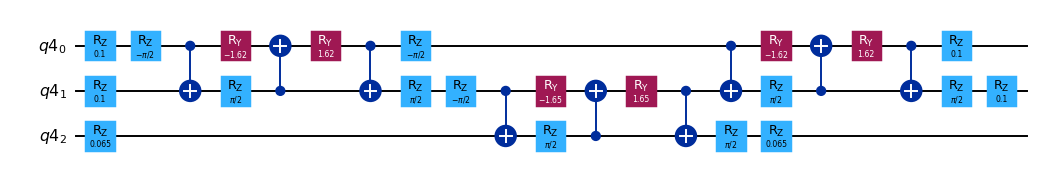

In [48]:
from IPython.display import display

def get_manual_Trotter(num_q, pauli_ops, timestep, n_trotter=1,
                       trotter_type='basic', reverse_bits=True):
    # sorts the Pauli strings according to qubit number they affect and symmetry
    one_q, even_two_q, odd_two_q = sort_Pauli_by_symmetry(pauli_ops)
    # scales the timestep according to the number of trotter steps
    timestep_even_two_q = timestep / n_trotter
    timestep_odd_two_q = timestep / n_trotter
    timestep_one_q = timestep / n_trotter
    # symmetric places 1/2 of one_q and odd_two_q before and after even_two_q
    if trotter_type == 'symmetric':
        timestep_odd_two_q /= 2
        timestep_one_q /= 2
    # constructs circuits for each segment of the operators
    qc_odd_two_q, qc_even_two_q, qc_one_q = QuantumCircuit(num_q), QuantumCircuit(num_q), QuantumCircuit(num_q)
    for i in even_two_q:
        qc_even_two_q = generate_circ_pattern_2qubit(qc_even_two_q, i, timestep_even_two_q)
    for i in odd_two_q:
        qc_odd_two_q = generate_circ_pattern_2qubit(qc_odd_two_q, i, timestep_odd_two_q)
    for i in one_q:
        qc_one_q = generate_circ_pattern_1qubit(qc_one_q, i, timestep_one_q)
    # assembles the circuit for Trotter decomposition of exponential
    qr = QuantumRegister(num_q)
    qc = QuantumCircuit(qr)
    if trotter_type == 'basic':
        qc = qc.compose(qc_even_two_q)
        qc = qc.compose(qc_odd_two_q)
        qc = qc.compose(qc_one_q)
    elif trotter_type == 'symmetric':
        qc = qc.compose(qc_one_q)
        qc = qc.compose(qc_odd_two_q)
        qc = qc.compose(qc_even_two_q)
        qc = qc.compose(qc_odd_two_q)
        qc = qc.compose(qc_one_q)
    # repeats the single_trotter circuit several times to match n_trotter
    for i in range(n_trotter-1):
        qc = qc.compose(qc)
    if reverse_bits:
        return qc.reverse_bits()
    else:
        return qc
    
# Jalankan fungsi
qc_basic = get_manual_Trotter(
    num_q=num_q,
    pauli_ops=sum(spin_chain_hamiltonian),
    timestep=evolution_timestep,
    n_trotter=n_trotter_steps,
    trotter_type='basic'
)

qc_symmetric = get_manual_Trotter(
    num_q=num_q,
    pauli_ops=sum(spin_chain_hamiltonian),
    timestep=evolution_timestep,
    n_trotter=n_trotter_steps,
    trotter_type='symmetric'
)

print("Basic depth:    ", qc_basic.depth())
print("Symmetric depth:", qc_symmetric.depth())

print("\nBasic ops:    ", qc_basic.count_ops())
print("Symmetric ops:", qc_symmetric.count_ops())

# Basic
print("=== BASIC ===")
display(qc_basic.draw('mpl', scale=0.7))

# Symmetric
print("=== SYMMETRIC ===")
display(qc_symmetric.draw('mpl', scale=0.7))



### SCRIPT 4.28 ###
- Manual Trotter Circuits

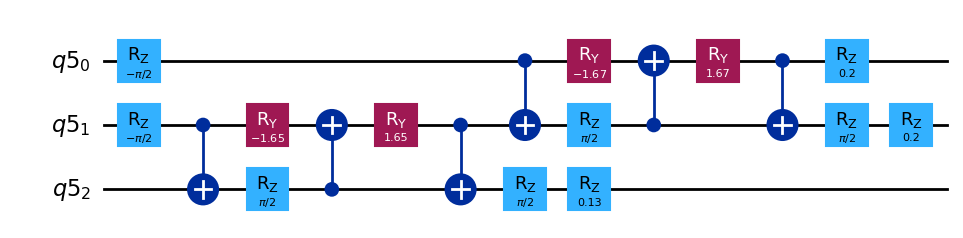

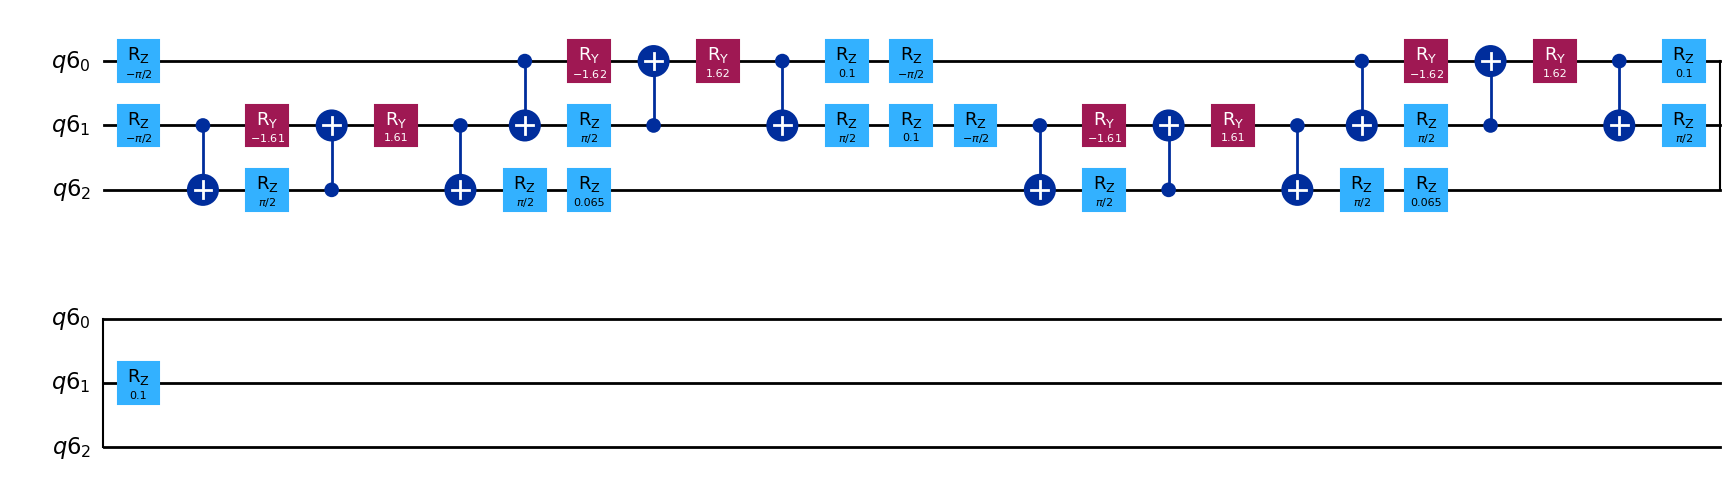

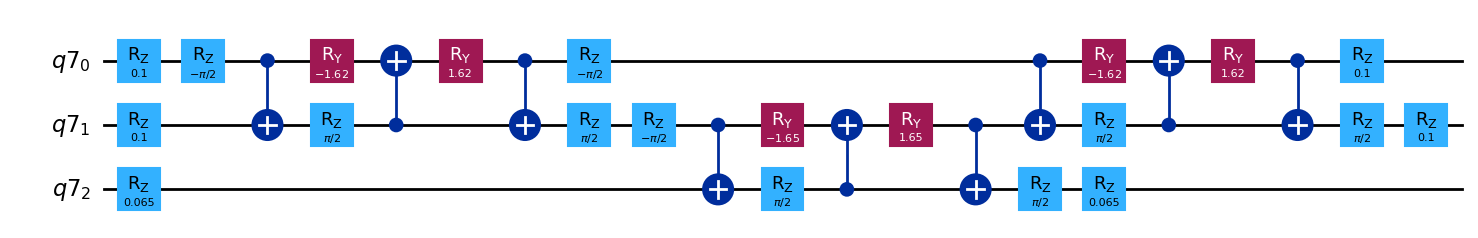

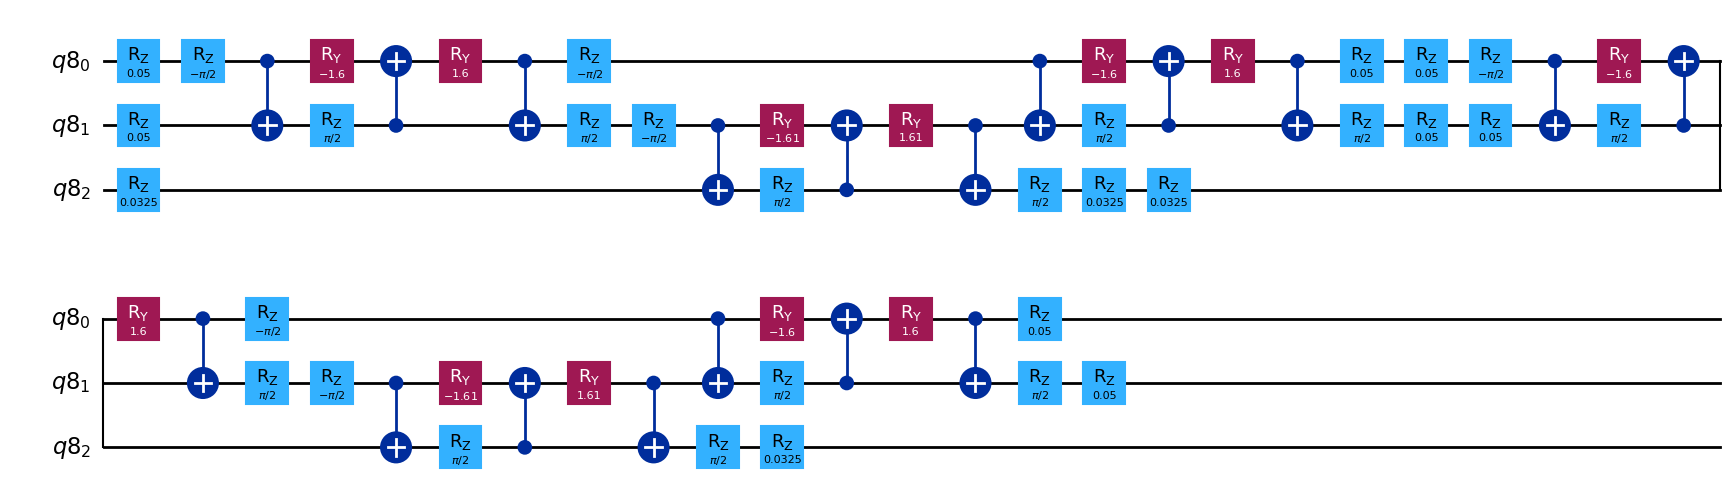

In [49]:
spin_chain_hamiltonian = get_heisenberg_hamiltonian(num_q, ham_coeffs)
spin_chain_hamiltonian = sum(spin_chain_hamiltonian)
display(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1).draw('mpl'))
display(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1,n_trotter=2).draw('mpl'))
display(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, trotter_type='symmetric').draw('mpl'))
display(get_manual_Trotter(num_q, spin_chain_hamiltonian, 0.1, n_trotter=2,trotter_type='symmetric').draw('mpl'))

### SCRIPT 4.29 ###
- Quantum Circuit Initialization

In [50]:
from qiskit import QuantumRegister, ClassicalRegister

# specifying a quantum register with specific number of qubits
qr = QuantumRegister(num_q, name='q')
# classical register used for measurement of qubits
cr = ClassicalRegister(num_q, name='c')
# quantum circuit combining quantum and classical registers
qc = QuantumCircuit(qr, cr) # instantiated here
qc.draw('mpl')
print(qc)


     
q_0: 
     
q_1: 
     
q_2: 
     
c: 3/
     


### SCRIPT 4.30 ###
- Quantum Circuit for Vacuum State Initialization

In [51]:
# specifying initial state by flipping qubit states
for qubit_idx in range(num_q):
    if qubit_idx == 0:
        # generate only one spin-up at first qubit
        qc.id(qubit_idx)
    else:
        # make all other spins have the spin-down state
        qc.x(qubit_idx)
qc.barrier()
qc.draw('mpl')
print(qc)

# checking the initial state
qc_init_state = Statevector(qc)
print(qc_init_state)

     ┌───┐ ░ 
q_0: ┤ I ├─░─
     ├───┤ ░ 
q_1: ┤ X ├─░─
     ├───┤ ░ 
q_2: ┤ X ├─░─
     └───┘ ░ 
c: 3/════════
             
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


### SCRIPT 4.31 ###
-  State Initialization: Amplitude Encoding

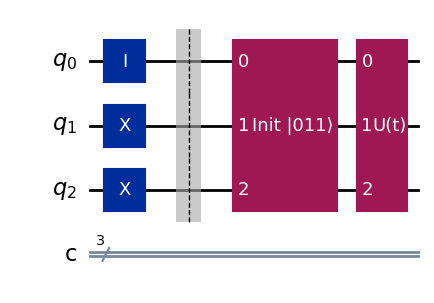

In [52]:
qr_init = QuantumRegister(num_q)
qc_init = QuantumCircuit(qr_init)
qc_init.initialize('011', qr_init[:])
qc_init.name = "Init |011⟩"

qc.append(qc_init, qr[:])

qc_basic.name = "U(t)"

qc.append(qc_basic, qr[:])
qc.draw('mpl')

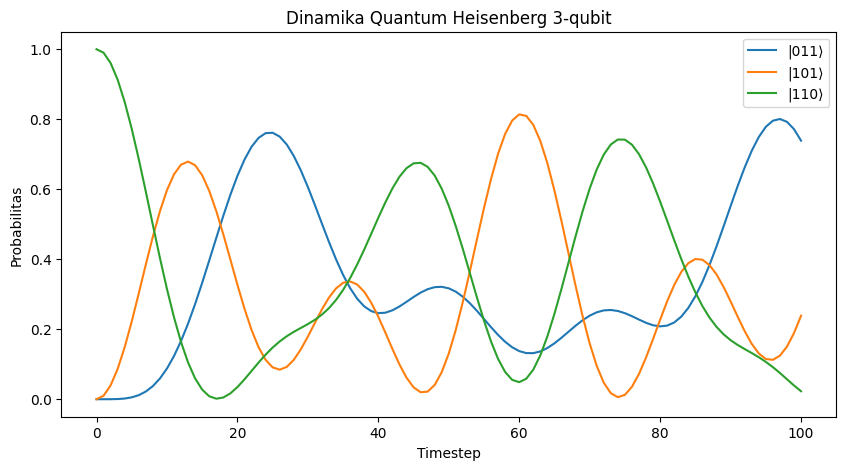

In [53]:
# Fungsi qsolve_statevector adalah inti dari loop propagasi waktu 
# yang menghubungkan semua kode sebelumnya
# Cell 1: Definisi fungsi
def qsolve_statevector(psin, qc):
    n    = np.size(psin)
    d    = int(np.log2(np.size(psin)))
    qre  = QuantumRegister(d)
    circ = QuantumCircuit(qre)
    circ.initialize(psin, qre)
    circ.barrier()
    circ.append(qc, qre)
    circ.barrier()
    psin = Statevector(circ)
    return np.array(psin)

Nsteps = 100  # sesuaikan dengan kebutuhan
# Cell 2: Loop propagasi
psin    = np.array([0,0,0,0,0,0,1,0], dtype=complex)  # |011⟩
results = [np.abs(psin)**2]

for step in range(Nsteps):
    psin = qsolve_statevector(psin, qc_basic)
    results.append(np.abs(psin)**2)

# Cell 3: Plot
labels = ['|000⟩', '|001⟩', '|010⟩', '|011⟩', 
          '|100⟩', '|101⟩', '|110⟩', '|111⟩']

results_arr = np.array(results)

plt.figure(figsize=(10, 5))
for i in range(8):
    if np.max(results_arr[:, i]) > 0.01:  # hanya plot yang signifikan
        plt.plot(results_arr[:, i], label=labels[i])

plt.xlabel('Timestep')
plt.ylabel('Probabilitas')
plt.title('Dinamika Quantum Heisenberg 3-qubit')
plt.legend()
plt.show()

### SCRIPT 4.32 ###
- Applying Time Evolution Operator to Circuit

     ┌───┐ ░ ┌─────────────┐┌───────┐┌───────────────┐ ░ 
q_0: ┤ I ├─░─┤0            ├┤0      ├┤0              ├─░─
     ├───┤ ░ │             ││       ││               │ ░ 
q_1: ┤ X ├─░─┤1 Init |011⟩ ├┤1 U(t) ├┤1 circuit-5996 ├─░─
     ├───┤ ░ │             ││       ││               │ ░ 
q_2: ┤ X ├─░─┤2            ├┤2      ├┤2              ├─░─
     └───┘ ░ └─────────────┘└───────┘└───────────────┘ ░ 
c: 3/════════════════════════════════════════════════════
                                                         
Depth of the circuit is 4
Depth of the circuit after transpilation is 12


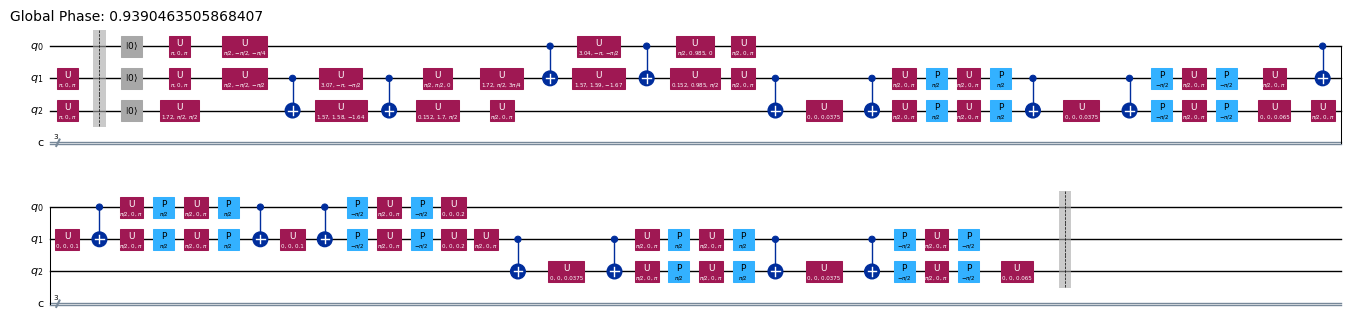

In [54]:
# generating the time evolution operator for a specific set of
# hamiltonian parameters and timestep
time_evo_op = get_time_evolution_operator(num_qubits=num_q,
        tau=evolution_timestep,
        trotter_steps=n_trotter_steps,
        coeff=ham_coeffs)

# appending the Hamiltonian evolution to the circuit
qc.append(time_evo_op, list(range(num_q)))
qc.barrier()
qc.draw(style='iqp')
print(qc)

# Depth check
print('Depth of the circuit is', qc.depth())
# transpiled circuit to statevector simulator
device = AerSimulator(method='statevector')
qct = transpile(qc, device, optimization_level=2)
print('Depth of the circuit after transpilation is ' f'{qct.depth()}')

# Decompose sampai gate dasar
qct_decomposed = qct.decompose().decompose().decompose()

# Plot
display(qct_decomposed.draw('mpl', scale=0.5, fold=40))

### SCRIPT 4.34 ###
- Statevector Experiment

[0 0 0 1 0 0 0 0]
Running dynamics step 0
Running dynamics step 1
Running dynamics step 2
Running dynamics step 3
Running dynamics step 4
Running dynamics step 5
Running dynamics step 6
Running dynamics step 7
Running dynamics step 8
Running dynamics step 9
Running dynamics step 10
Running dynamics step 11
Running dynamics step 12
Running dynamics step 13
Running dynamics step 14
Running dynamics step 15
Running dynamics step 16
Running dynamics step 17
Running dynamics step 18
Running dynamics step 19
Running dynamics step 20
Running dynamics step 21
Running dynamics step 22
Running dynamics step 23
Running dynamics step 24
Running dynamics step 25
Running dynamics step 26
Running dynamics step 27
Running dynamics step 28
Running dynamics step 29
Running dynamics step 30
Running dynamics step 31
Running dynamics step 32
Running dynamics step 33
Running dynamics step 34
Running dynamics step 35
Running dynamics step 36
Running dynamics step 37
Running dynamics step 38
Running dynamics 

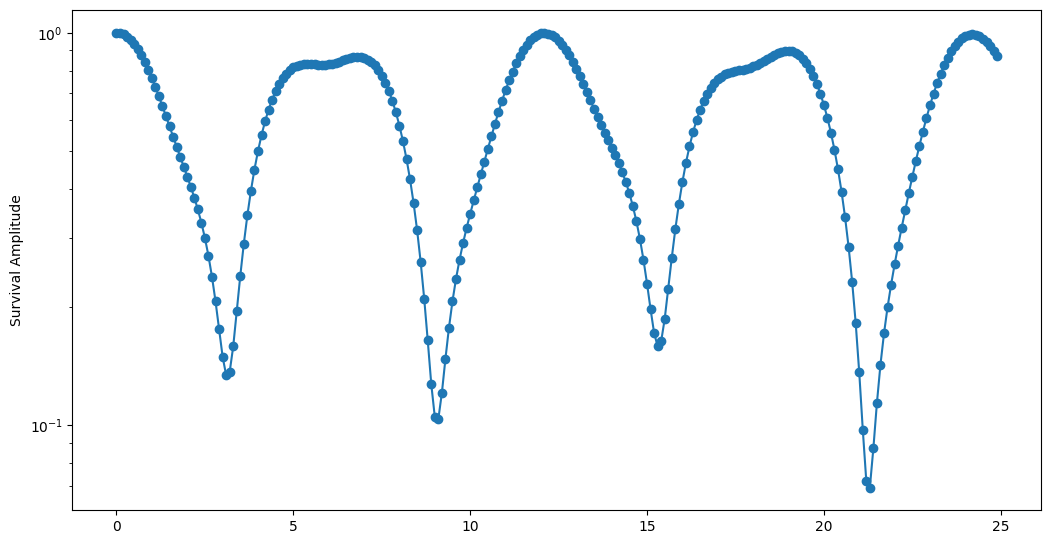

In [77]:
# Qubit basis states
zero_state = np.array([[1],[0]])
one_state = np.array([[0],[1]])

# For a 011 initial state prepare as follows
psin = zero_state # for the first spin
# iterates over the remaining spins, by performing
# Kronecker Product
for i in range(num_q-1):
    psin = np.kron(psin, one_state)
psin0 = psin.flatten()
print(psin0)

# time evolution operator
time_evo_op = get_time_evolution_operator(num_qubits=num_q,
        tau=evolution_timestep,
        trotter_steps=n_trotter_steps,
        coeff=ham_coeffs)
# number of steps for which to propagate
# (totaling 25 units of time)
nsteps = 250
psin_list = []
psin_list.append(psin0)
correlation_list = []
# performs dynamical propagation by statevector re-initialization
for k in range(nsteps):
    print(f'Running dynamics step {k}')
    if k > 0:
        psin = qsolve_statevector(psin_list[-1], time_evo_op)
        # removes the last initial state to save memory
        psin_list.pop()
        # stores the new initial state
        psin_list.append(psin)
    correlation_list.append(np.vdot(psin_list[-1],psin0))

t = np.arange(0, evolution_timestep*(nsteps),
                evolution_timestep)
np.save(f'{num_q}_spin_chain_time', t)
sa_observable = np.abs(correlation_list)
np.save(f'{num_q}_spin_chain_SA_obs', sa_observable)
# plotting
plt.plot(t, sa_observable, '-o')
plt.ylabel('Survival Amplitude')
plt.yscale('log')
plt.show()

### SCRIPT 4.35 ###
- Hadamard Test Function

In [56]:
def get_hadamard_test(num_q, initial_state, control_operation,
                      control_repeats=0, imag_expectation=False):
    '''
        Writes the Hadamard test circuit to evaluate the real (or imaginary)
        components of a given operator (or set of operators) by measuring the
        ancilla.

        Inputs:
            num_qubits (int): number of qubits needed for the calculation
            initial_state: quantum circuit object containing the initialization
                for the system
            control_operation: quantum circuit object containing the controlled
                version of the unitary operator for which to evaluate the
                expectation value
            control_repeats (int): number of repetitions of the controlled
                operation in the Hadamard test circuit (such as time-propagation)
            imag_expectation (boolean): whether to assemble the circuit for
                evaluation of the real or imaginary components of the operator.
        Returns:
            qc_hadamard: quantum circuit object containing the hadamard test
    '''
    # Circuit object framework
    qr_hadamard = QuantumRegister(num_q+1)
    cr_hadamard = ClassicalRegister(1)
    qc_hadamard = QuantumCircuit(qr_hadamard, cr_hadamard) # instantiated here
    # Initialization of calculation qubits
    qc_hadamard.append(initial_state, qr_hadamard[1:]) # initial psi
    qc_hadamard.barrier()
    # Hadamard test structure
    qc_hadamard.h(0)
    if imag_expectation:
        qc_hadamard.p(-np.pi/2, 0) # qc_hadamard.s(0).inverse() may be equivalent
    # iterates over the number of times the control operation should be added
   # Auto-detect apakah sudah controlled atau belum
    for i in range(control_repeats):
        if control_operation.num_qubits == num_q:
            # Belum controlled → tambah control qubit
            qc_hadamard.append(control_operation.control(1), qr_hadamard[:])
        elif control_operation.num_qubits == num_q + 1:
            # Sudah controlled → langsung pakai semua qubit
            qc_hadamard.append(control_operation, qr_hadamard[:])
        else:
            raise ValueError(f"control_operation punya {control_operation.num_qubits} qubit, "
                             f"tapi harusnya {num_q} atau {num_q+1}")
    qc_hadamard.h(0)
    qc_hadamard.barrier()
    # Measuring the ancilla
    qc_hadamard.measure(0,0)
    return qc_hadamard

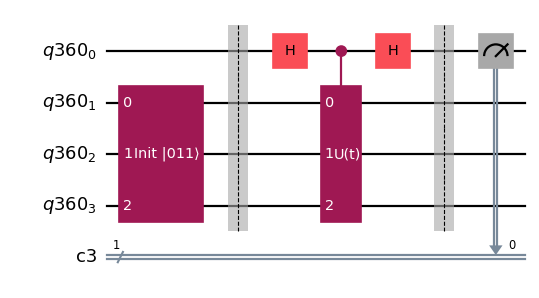

In [57]:
# Buat Trotter circuit tanpa classical register
qc_basic_ctrl = get_manual_Trotter(
    num_q=num_q,
    pauli_ops=spin_chain_hamiltonian,
    timestep=evolution_timestep,
    n_trotter=n_trotter_steps,
    trotter_type='basic'
)
qc_basic_ctrl.name = "U(t)"

# Convert ke gate murni tanpa classical register
qc_basic_ctrl = qc_basic_ctrl.to_gate()
qc_basic_ctrl.label = "U(t)"

qc_init.name = "Init |011⟩"

# Pakai fungsi asli
qc_hadamard = get_hadamard_test(
    num_q=num_q,
    initial_state=qc_init,
    control_operation=qc_basic_ctrl,
    control_repeats=1,
    imag_expectation=False
)

qc_hadamard.draw('mpl', scale=0.8, style='iqp')

### SCRIPT 4.36 ###
- Hadamard Test Post-Processing

In [58]:
def get_spin_correlation(counts):
    '''
        Generates the spin correlation at a particular time by averaging over
        the counts of the ancillary qubit.
    '''

    qubit_to_spin_map = {
        '0': 1,
        '1': -1,
    }
    total_counts = 0
    values_list = []
    for k,v in counts.items():
        values_list.append(qubit_to_spin_map[k] * v)
        total_counts += v
    # print(values_list)
    average_spin = (sum(values_list)) / total_counts
    return average_spin

In [59]:
# Buat tau outputnya
# Bagian REAL (imag_expectation=False)
qc_real = get_hadamard_test(
    num_q=num_q,
    initial_state=qc_init,
    control_operation=qc_basic_ctrl,
    control_repeats=1,
    imag_expectation=False  # ← real
)
result_real = simulator.run(transpile(qc_real, simulator), shots=1000).result()
real_part   = get_spin_correlation(result_real.get_counts())

# Bagian IMAJINER (imag_expectation=True)
qc_imag = get_hadamard_test(
    num_q=num_q,
    initial_state=qc_init,
    control_operation=qc_basic_ctrl,
    control_repeats=1,
    imag_expectation=True   # ← imajiner
)
result_imag = simulator.run(transpile(qc_imag, simulator), shots=1000).result()
imag_part   = get_spin_correlation(result_imag.get_counts())

# Nilai harap lengkap
print(f"Re⟨ψ|U|ψ⟩ = {real_part}")
print(f"Im⟨ψ|U|ψ⟩ = {imag_part}")
print(f"⟨ψ|U|ψ⟩   = {real_part + 1j*imag_part}")

Re⟨ψ|U|ψ⟩ = 0.128
Im⟨ψ|U|ψ⟩ = -0.99
⟨ψ|U|ψ⟩   = (0.128-0.99j)


### SCRIPT 4.37 ###
- Creation of Controled Time-Evolution Operator

In [60]:
evolution_timestep=0.1
total_time = 25
time_range = np.arange(0, total_time+evolution_timestep,
                        evolution_timestep)

controlled_time_evo_op = time_evo_op.control()

def get_initialization(num_q, init_state_list):
    qr = QuantumRegister(num_q)
    qc = QuantumCircuit(qr)
    qc.initialize(init_state_list, qr[:])
    qc.name = f"Init |{init_state_list}⟩"
    return qc

init_state_list = '1' + '0' * (num_q-1)
init_circ = get_initialization(num_q, init_state_list)
init_circ.draw(style='iqp')
print(init_circ)

        ┌────────────────────┐
q364_0: ┤0                   ├
        │                    │
q364_1: ┤1 Initialize(1,0,0) ├
        │                    │
q364_2: ┤2                   ├
        └────────────────────┘


### SCRIPT 4.38 ###
- Hadamard Test Execution

In [74]:
# IMPORTANT: Use qasm_simulator to obtain meaningful statistics
# statevector is not appropriate for this method

def get_circuit_execution_counts(qc, simulator, n_shots=1000):
    compiled = transpile(qc, simulator)
    result   = simulator.run(compiled, shots=n_shots).result()
    return result.get_counts()

num_shots = 1000  # jumlah pengukuran per timestep

# Definisi time range sesuai plot
t_max = 25
evolution_timestep = 0.1
n_steps = int(t_max / evolution_timestep)
time_range = np.linspace(0, t_max, n_steps)

real_amp_list = []
imag_amp_list = []

simulator = AerSimulator()
real_amp_list = []
imag_amp_list = []
for idx,time in enumerate(time_range):
    print(f'Running dynamics step {idx}')
    # Real component ------------------------------
    qc_had_real = get_hadamard_test(num_q, init_circ,
                                    controlled_time_evo_op,
                                    control_repeats=idx,
                                    imag_expectation=False)
    had_real_counts = get_circuit_execution_counts(
            qc_had_real, simulator, n_shots=num_shots)
    real_amplitude = get_spin_correlation(had_real_counts)
    real_amp_list.append(real_amplitude)

    # Imag component ------------------------------
    qc_had_imag = get_hadamard_test(num_q, init_circ,
                                    controlled_time_evo_op,
                                    control_repeats=idx,
                                    imag_expectation=True)
    had_imag_counts = get_circuit_execution_counts(
            qc_had_imag, simulator, n_shots=num_shots)
    imag_amplitude = get_spin_correlation(had_imag_counts)
    imag_amp_list.append(imag_amplitude)
    print(f'Finished step {idx}, where '
            f'Re = {real_amplitude:.3f} '
            f'Im = {imag_amplitude:.3f}')

real_amp_array = np.array(real_amp_list)
imag_amp_array = np.array(imag_amp_list)



Running dynamics step 0
Finished step 0, where Re = 1.000 Im = 0.012
Running dynamics step 1
Finished step 1, where Re = 0.986 Im = -0.152
Running dynamics step 2
Finished step 2, where Re = 0.956 Im = -0.242
Running dynamics step 3
Finished step 3, where Re = 0.894 Im = -0.354
Running dynamics step 4
Finished step 4, where Re = 0.804 Im = -0.494
Running dynamics step 5
Finished step 5, where Re = 0.714 Im = -0.610
Running dynamics step 6
Finished step 6, where Re = 0.584 Im = -0.706
Running dynamics step 7
Finished step 7, where Re = 0.534 Im = -0.742
Running dynamics step 8
Finished step 8, where Re = 0.372 Im = -0.756
Running dynamics step 9
Finished step 9, where Re = 0.270 Im = -0.774
Running dynamics step 10
Finished step 10, where Re = 0.104 Im = -0.744
Running dynamics step 11
Finished step 11, where Re = 0.034 Im = -0.770
Running dynamics step 12
Finished step 12, where Re = -0.080 Im = -0.690
Running dynamics step 13
Finished step 13, where Re = -0.234 Im = -0.656
Running dyn

In [79]:
print('Saving data...')
# real and imaginary amplitude components
np.savetxt('real_amp_array.csv', real_amp_array,
            fmt='%.18e', delimiter=';', newline='\n')
np.savetxt('imag_amp_array.csv', imag_amp_array,
            fmt='%.18e', delimiter=';', newline='\n')
# survival amplitude
np.savetxt('np_abs_correlation_with_hadamard_test.csv',
            np.abs(real_amp_array + 1j*imag_amp_array),
            fmt='%.18e', delimiter=';', newline='\n')
# survival probability
np.savetxt('np_sqrt_sum_squares_correlation_with_hadamard'
            '_test.csv',
            np.sqrt(real_amp_array**2 + imag_amp_array**2),
            fmt='%.18e', delimiter=';', newline='\n')
real_amp_array = np.loadtxt('real_amp_array.csv',
                        delimiter=';')
imag_amp_array = np.loadtxt('imag_amp_array.csv',
                        delimiter=';')
np_abs_correlation_with_hadamard_test = np.loadtxt(
    'np_abs_correlation_with_hadamard_test.csv',
    delimiter=';')
np_sqrt_sum_squares_correlation_with_hadamard_test = np.loadtxt(
    'np_sqrt_sum_squares_correlation_with_hadamard_test.csv',
    delimiter=';')

Saving data...


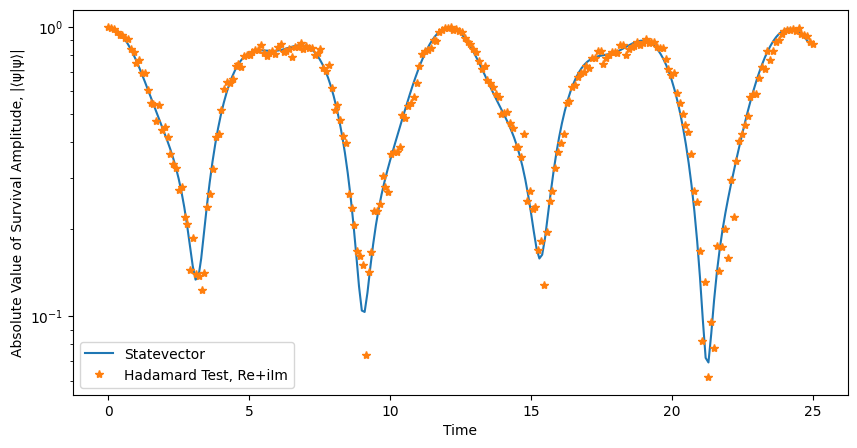

In [81]:
abs_correlation = np.abs(real_amp_array + 1j * imag_amp_array)

sa_statevector = np.load('3_spin_chain_SA_obs.npy')
time_sv = np.load('3_spin_chain_time.npy')

plt.figure(figsize=(10, 5))
plt.plot(time_sv, sa_statevector, '-', label='Statevector')
plt.plot(time_range, abs_correlation, '*', label='Hadamard Test, Re+iIm')
plt.xlabel('Time')
plt.ylabel('Absolute Value of Survival Amplitude, |⟨ψ|ψ⟩|')
plt.yscale('log')
plt.legend()
plt.show()

### SCRIPT 4.39 ###
- Variation Quantum Real Time Evolution

In [89]:
import numpy as np
from qiskit_algorithms import VarQRTE, TimeEvolutionProblem
from qiskit.circuit.library import ExcitationPreserving
from qiskit_algorithms.time_evolvers.variational import RealMcLachlanPrinciple
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp

var_principle = RealMcLachlanPrinciple()
estimator = Estimator()
total_time = 5.0
evolution_timestep = 0.2

hamiltonian = SparsePauliOp.from_list([("ZI", 0.5), ("IZ", 0.5), ("XX", 0.2)])

def init_circ():
    qc = QuantumCircuit(2,0)
    qc.x(0) # initial state is |10>
    return qc

# Anstaz at t=0 must be equal to the Identity
params = [np.array([0.0 for i in range(5)])]
anstaz = ExcitationPreserving(num_qubits=2, entanglement='linear', reps=1)
anstaz = init_circ().compose(anstaz)

# Define and Run the Time Evolution Problem
evolution_problem = TimeEvolutionProblem(hamiltonian, total_time)
qrte = VarQRTE(anstaz, params[0][:], variational_principle=var_principle, estimator=estimator, num_timesteps=int(total_time/evolution_timestep))
params = qrte.evolve(evolution_problem).parameter_values

# Assemble the circuit which creates the evolved state
evolved_circ = anstaz.assign_parameters(params[-1])
print("=== VarQRTE Selesai ===")
print(f"Total waktu evolusi : {total_time}")
print(f"Timestep            : {evolution_timestep}")
print(f"Jumlah timesteps    : {int(total_time/evolution_timestep)}")
print(f"Jumlah parameter    : {len(params[-1])}")
print(f"Parameter akhir     : {params[-1]}")
print(f"Jumlah qubit        : {evolved_circ.num_qubits}")
print(f"Depth circuit       : {evolved_circ.depth()}")
print("\nEvolved Circuit:")
print(evolved_circ)


/tmp/ipykernel_4063338/971200695.py:23: DeprecationWarning: The class ``qiskit.circuit.library.n_local.excitation_preserving.ExcitationPreserving`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.excitation_preserving instead.
  anstaz = ExcitationPreserving(num_qubits=2, entanglement='linear', reps=1)


=== VarQRTE Selesai ===
Total waktu evolusi : 5.0
Timestep            : 0.2
Jumlah timesteps    : 25
Jumlah parameter    : 5
Parameter akhir     : [-2.72623856e-17  6.03072674e-17  1.00000000e+00 -2.92915326e-16
  3.18399498e-16]
Jumlah qubit        : 2
Depth circuit       : 2

Evolved Circuit:
     ┌───┐┌──────────────────────────────────┐
q_0: ┤ X ├┤0                                 ├
     └───┘│  ExcitationPreserving(0,0,1,0,0) │
q_1: ─────┤1                                 ├
          └──────────────────────────────────┘


### SCRIPT 4.40 ###
- Variational Quantum Eigensolver

/tmp/ipykernel_4063338/1025182132.py:20: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(hamiltonian.num_qubits)


Energy: -0.03411254883118091
Energy: -0.5359482782655633
Energy: -0.5131934786555188
Energy: -0.20939010010998446
Energy: -0.1589793657860024
Energy: -0.5635395993575948
Energy: -0.8427219036399844
Energy: -0.509793171690244
Energy: -0.4942170688109552
Energy: -0.6042736253092071
Energy: -0.6851645080441948
Energy: -0.8087583007638806
Energy: -0.8574024144165227
Energy: -0.6714285903687198
Energy: -0.6933261607635068
Energy: -0.8153509283898024
Energy: -0.815453329787841
Energy: -0.6351031456430838
Energy: -0.8738626046416094
Energy: -0.8275096990792624
Energy: -0.8159281991987103
Energy: -0.785615986352515
Energy: -0.863790236736816
Energy: -0.9069361908509663
Energy: -0.9128672766331198
Energy: -0.8923291051587512
Energy: -0.8489765944789007
Energy: -0.9048922985238829
Energy: -0.846671317322369
Energy: -0.9083960193811405
Energy: -0.9990808474229285
Energy: -0.8812181012889028
Energy: -0.9992480287048843
Energy: -1.0069277338679437
Energy: -1.0100012541002814
Energy: -0.943827462816

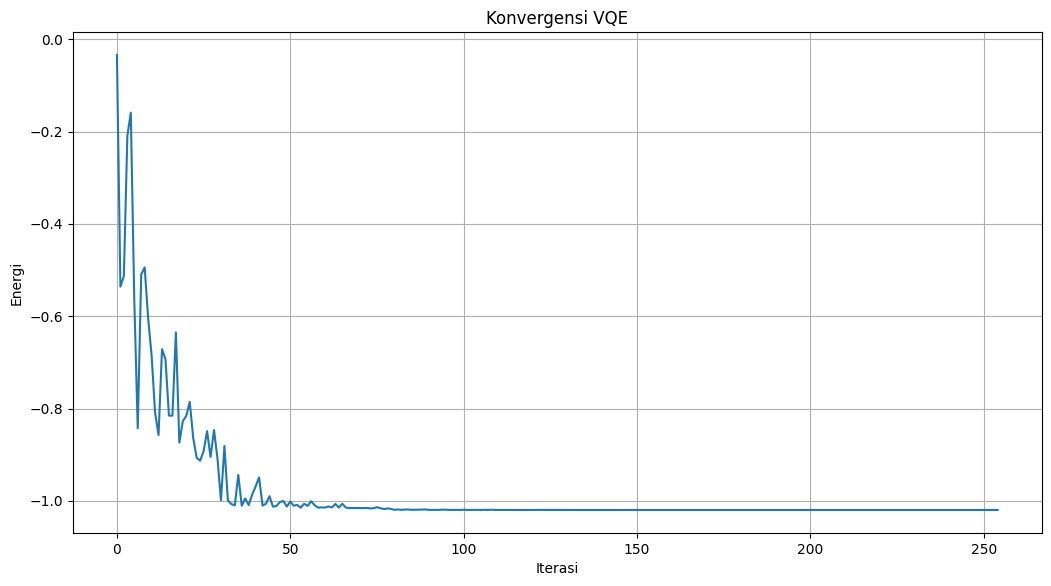

In [ ]:
from qiskit.circuit.library import EfficientSU2
from scipy.optimize import minimize
from qiskit.primitives import StatevectorEstimator as Estimator

estimator = Estimator()
hamiltonian = SparsePauliOp.from_list([("ZI", 0.5), ("IZ", 0.5), ("XX", 0.2)])

energy_history = []

#Estimate the energy using a quantum computer
def energy(params, ansatz, hamiltonian, estimator):
    current_energy = estimator.run([(ansatz, hamiltonian, params)]).result()[0].data.evs
    # pub = (ansatz, hamiltonian, params)
    # current_energy = estimator.run([pub]).result()[0].data.evs
    energy_history.append(float(current_energy))
    print("Energy: "+str(current_energy))
    return current_energy

# Define the ansatz which will be used to prepare the ground state
ansatz = EfficientSU2(hamiltonian.num_qubits)

initial_params = np.random.random(ansatz.num_parameters)

# Now run the minimization algorithm to minimize the energy
res = minimize(energy, initial_params,
        args=(ansatz, hamiltonian, estimator), method="cobyla")

# Lastly, output the energy estimate obtained
final_params = res.x
print("Final Energy Estimate: "+str(energy(final_params, ansatz, hamiltonian, estimator)))

# Kode tambahan
# Cek dulu isi list-nya
print("Jumlah iterasi:", len(energy_history))
print("Isi energy_history:", energy_history)

plt.plot(energy_history)
plt.xlabel("Iterasi")
plt.ylabel("Energi")
plt.title("Konvergensi VQE")
plt.grid(True)
plt.show()

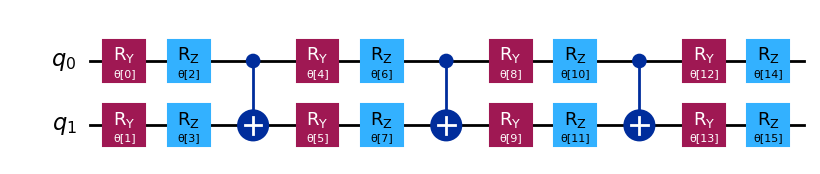

In [98]:
ansatz.decompose().draw("mpl")

### SCRIPT 5.1 ###
-  Bose Hubbard Hamiltonian Global Parameters

In [4]:
import numpy as np
cutoff = 10 # Number of levels per bosonic mode (Fock dimension truncation)
J = 1 # Hopping term
U = 1.5 # On-site interaction potential
k = 20 # Number of Trotter layers
t = 1.086 # Evolution time
theta = -J*t/k
r = -U*t/(2*k)
# Prepare the initial statevector
ket = np.zeros([10]*2, dtype=np.complex64)
ket[2,0] = 1.0 + 0.0j   #Jadi state awalnya adalah |2,0⟩ → 2 foton di mode pertama, 0 foton di mode kedua.

### SCRIPT 5.2 ###
-  Evolving Bose-Hubbard Hamiltonian

In [5]:
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson

import strawberryfields as sf
# Declare Program
prog = sf.Program(2)
# Define quantum circuit
with prog.context as q:
    # Prepare initial quantum state
    sf.ops.Ket(ket) | q
    # For-loop to define each of the $k$ Trotter layers
    for i in range(k):
        sf.ops.BSgate(theta, np.pi/2) | (q[0],q[1]) # Parametrized beamsplitter gate applied on the first and second qumode
        sf.ops.Kgate(r) | q[0] # Parametrized kerr gate applied on the first qumode
        sf.ops.Rgate(-r) | q[0] # Parametrized rotation gate applied on the first qumode
        sf.ops.Kgate(r) | q[1]
        sf.ops.Rgate(-r) | q[1]
        # end circuit

# Define the engine backend and execute the circuit
eng = sf.Engine('fock', backend_options={"cutoff_dim":cutoff})
state = eng.run(prog).state

# Print the output state probabilities
print(state.fock_prob([0,2]))
print(state.fock_prob([1,1]))
print(state.fock_prob([2,0]))

0.5224012457200216
0.235652876856725
0.2419458774232605


### SCRIPT 5.3 ###
- Calculating Energy of evolved state

In [6]:
import numpy as np
cutoff = 10 # Fock dimension truncation

def hopping_term(statevec):
    svc = np.conj(statevec)
    hop = 0
    for i in range(cutoff):
        if i == 0:
            for j in range(1,cutoff):
                hop += (svc[i,j]*np.sqrt((i+1)*j)*statevec[i+1,j-1])
        else:
            for j in range(cutoff-1):
                hop += (svc[i,j]*np.sqrt(i*(j+1))*statevec[i-1,j+1])
            if i < cutoff-1:
                for x in range(1,cutoff):
                    hop += (svc[i,x]*np.sqrt((i+1)*x)*statevec[i+1,x-1])
    return np.abs(hop*J)

def on_site(statevec):
    on_site = 0
    for i in range(cutoff):
        for j in range(cutoff):
            on_site += np.abs(statevec[i,j])*(i**2+j**2-i-j)
    return np.abs(on_site*U/2)

sket = state.ket() # Extract resulting statevector
inner_prod = np.abs(np.vdot(sket,sket)) # Calculate statevector's norm
energy = (hopping_term(sket)+on_site(sket))/inner_prod # Calculate total energy
print(energy)

2.1356427750453006


### SCRIPT 5.4 ###
-  Setting up for performing VQE

In [10]:
import numpy as np
import math
import strawberryfields as sf
import tensorflow as tf
from matplotlib import pyplot as plt # for visualization

lr = 0.1 # Learning rate for TensorFlow optimizers
active_std = 0.001 # Standard deviations for normal distributions
passive_std = 0.1
tf.random.set_seed(42) # Global seed to ensure reproducibility over runs

### SCRIPT 5.5 ###
- Optimizing to coherent state via displacement gate

In [11]:
# Initialize engine, program objects, and parameters
eng = sf.Engine(backend="tf", backend_options={"cutoff_dim": 6})
circuit = sf.Program(1)
tf_r = tf.Variable(tf.random.normal(shape=[], stddev=0.001))
tf_phi = tf.Variable(tf.random.normal(shape=[], stddev=0.001))
r, phi = circuit.params("r", "phi")
# Define circuit
with circuit.context as q:
    sf.ops.Dgate(r, phi) | q[0]

opt = tf.keras.optimizers.Adam(learning_rate=0.1) # Define optimizer
steps = 100
best_fid = 0
# Target coherent state in Fock basis
alpha = 0.70710678118+0.70710678118j
coh = lambda a, dim: np.array([np.exp(-0.5 * np.abs(a) ** 2) * (a) ** n / np.sqrt(math.factorial(n)) for n in range(dim)])
target_statevec = coh(alpha,cutoff)
# Optimization starts here
for step in range(steps):

    # Reset the engine if it has already been executed
    if eng.run_progs:
        eng.reset()

    with tf.GradientTape() as tape:
        # Execute the engine
        results = eng.run(circuit, args={"r": tf_r, "phi": tf_phi})
        # Get the probability of fock state |1>
        fid = results.state.fidelity_coherent([alpha])
        # Save ket/statevector
        ket = results.state.ket()
        # Negative sign to maximize prob
        loss = 1-tf.sqrt(fid)

    gradients = tape.gradient(loss, [tf_r, tf_phi])
    opt.apply_gradients(zip(gradients, [tf_r, tf_phi]))
    print("Fidelity at step {}: {}".format(step, fid))
    if fid > best_fid:
        best_fid = fid
        best_r = tf_r
        best_phi = tf_phi
        learnt_state = ket.numpy()

    if step == 0:
        first_step_state = ket.numpy()

print(best_fid.numpy(),best_r.numpy(),best_phi.numpy())

Fidelity at step 0: 0.3680497407913208
Fidelity at step 1: 0.425284743309021
Fidelity at step 2: 0.4904964566230774
Fidelity at step 3: 0.5645244717597961
Fidelity at step 4: 0.646299421787262
Fidelity at step 5: 0.7328782677650452
Fidelity at step 6: 0.8188837170600891
Fidelity at step 7: 0.8962147831916809
Fidelity at step 8: 0.9547736048698425
Fidelity at step 9: 0.98550945520401
Fidelity at step 10: 0.9869115948677063
Fidelity at step 11: 0.9699659943580627
Fidelity at step 12: 0.9499538540840149
Fidelity at step 13: 0.9353771209716797
Fidelity at step 14: 0.9280575513839722
Fidelity at step 15: 0.9265667200088501
Fidelity at step 16: 0.9283618330955505
Fidelity at step 17: 0.931168258190155
Fidelity at step 18: 0.9340299367904663
Fidelity at step 19: 0.9376550912857056
Fidelity at step 20: 0.9435896277427673
Fidelity at step 21: 0.9527376294136047
Fidelity at step 22: 0.9644917249679565
Fidelity at step 23: 0.9769700169563293
Fidelity at step 24: 0.9878640174865723
Fidelity at ste

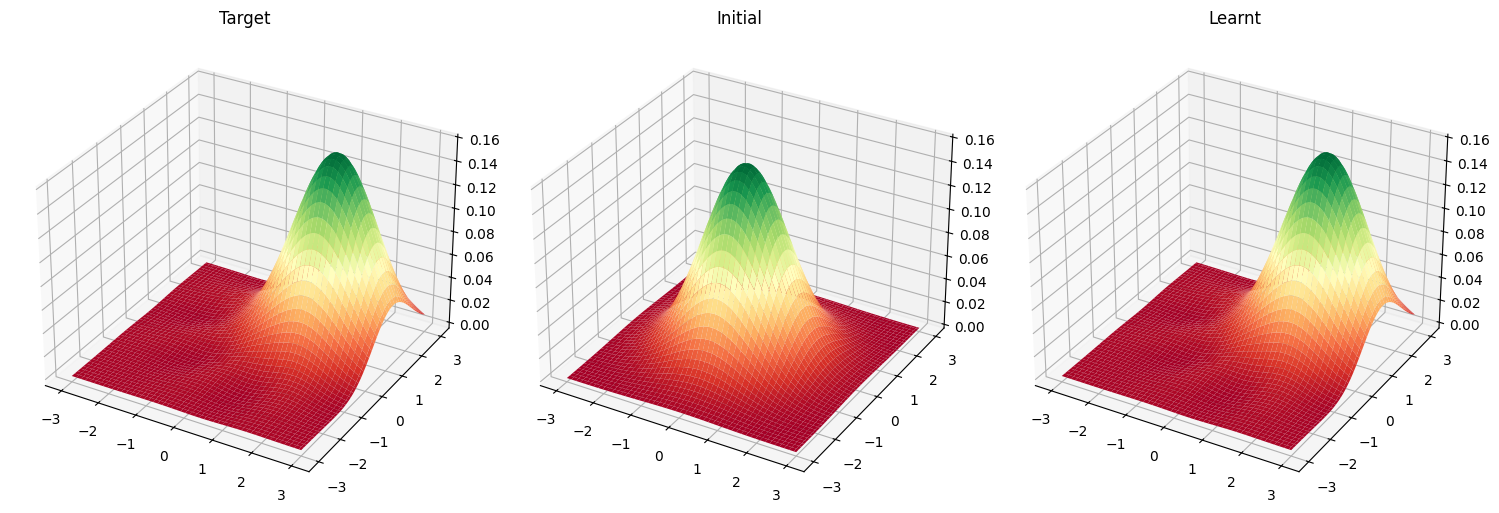

In [13]:
import matplotlib.pyplot as plt

xvec = np.linspace(-3, 3, 100)

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')

# Initial state (r=0, phi=0)
if eng.run_progs:
    eng.reset()
results_init = eng.run(circuit, args={"r": tf.constant(0.0), "phi": tf.constant(0.0)})
init_sf_state = results_init.state

# Target state (r=1.0003, phi=0.787)
if eng.run_progs:
    eng.reset()
results_target = eng.run(circuit, args={"r": tf.constant(1.0003), "phi": tf.constant(0.787)})
target_sf_state = results_target.state

# Learnt state (best parameters)
if eng.run_progs:
    eng.reset()
results_learnt = eng.run(circuit, args={"r": best_r, "phi": best_phi})
learnt_sf_state = results_learnt.state

for ax, sf_state, title in zip([ax1, ax2, ax3],
                                [target_sf_state, init_sf_state, learnt_sf_state],
                                ['Target', 'Initial', 'Learnt']):
    W = sf_state.wigner(0, xvec, xvec)
    X, P = np.meshgrid(xvec, xvec)
    ax.plot_surface(X, P, W, cmap='RdYlGn')
    ax.set_title(title)

plt.tight_layout()
plt.show()